# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Напишите заголовок первой части проекта здесь

- Автор: Фалеторов Кирилл
- Дата: 13.10.2025

## Цели и задачи проекта

Цель проекта:  
Проверить гипотезу о том, что пользователи из Санкт-Петербурга проводят больше времени в приложении Яндекс.Книги по сравнению с пользователями из Москвы.

Задачи проекта:  
1. Загрузить данные из файла yandex_knigi_data.csv. 
2. Проверить данные на дубликаты.
3. Сравнить размеры и статистику групп из Москвы и Санкт-Петербурга. 
4. Провести проверку гипотезы с помощью t-теста. 
5. Определить уровень значимости и интерпретировать результаты. 
6. Подготовить аналитическую записку с описанием тестов и их интерпретацией. 

## Описание данных

Данные, представленные в двух файлах, связаны с проведением A/B-тестов и содержат следующую информацию:  

Файл ab_test_participants.csv:  
- user_id: уникальный идентификатор пользователя.  
- group: группа, к которой принадлежит пользователь в рамках A/B-теста.  
- ab_test: название проводимого A/B-теста.  
- device: устройство, с которого пользователь зарегистрировался (например, компьютер, смартфон).  

Файл ab_test_events.zip (содержит csv-файл с событиями):  
- user_id: идентификатор пользователя, связанный с событием.  
- event_dt: дата и время, когда произошло событие.  
- event_name: тип события, например, регистрация или покупка.  
- details: дополнительные данные о событии. 

## Содержимое проекта

Загрузка данных и знакомство с ними  
Проверка гипотезы в Python  
Аналитическая записка

## 1. Загрузка данных и знакомство с ними



In [1]:
# Выгружаем библиотеки с которыми будем работать
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Загрузим библиотеку для проведения теста Манна-Уитни
from scipy.stats import mannwhitneyu

#Загрузим библиотеки для оценки достаточности выборки для получения статистически значимых результатов A/B-теста
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

#Загрузим библиотеку для проведения Z-теста
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Создаем датафрейм с данными
yandex_knigi= pd.read_csv('https://code.s3.yandex.net/datasets/yandex_knigi_data.csv')

yandex_knigi.info()

yandex_knigi.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [3]:
#Проверяем датасет на дубликаты по идентификатору пользователя
yandex_knigi.duplicated(subset=['puid']).sum()

244

In [4]:
# Удаляем дубликаты
yandex_knigi=yandex_knigi.drop_duplicates(subset=['puid'])
yandex_knigi.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8540 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8540 non-null   int64  
 1   city        8540 non-null   object 
 2   puid        8540 non-null   int64  
 3   hours       8540 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 333.6+ KB


В таблице ya_knigi 8783 строк и 4 столбца. Видим, что пропусков в данных нет, нужно проверить на дубликаты

In [5]:
#Для проведения теста, нам нужно убедиться, что выборки сопоставимы и независимы
#Группируем данные по городу и считаем уникальных пользователей
grp = ( yandex_knigi.groupby(['city']).agg({'puid': 'nunique'}).reset_index())

grp.head()

,city,puid
0,Москва,6234
1,Санкт-Петербург,2306


Группы независимы, так как нет пользователей, которые встречаются одновременно в двух группах.

Пользователей из Москвы почти в 3 раза больше, чем пользователей из Санкт-Петербурга, это может исказить результаты теста.  
В процессе обработки удалили 244 дубликата по идентификатору пользователя.

## 2. Проверка гипотезы в Python


- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [6]:
#Проверяем датасет на дубликаты по идентификатору пользователя
yandex_knigi.duplicated(subset=['puid']).sum()

0

In [7]:
# Удаляем дубликаты
yandex_knigi=yandex_knigi.drop_duplicates(subset=['puid'])
yandex_knigi.info()
yandex_knigi.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8540 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8540 non-null   int64  
 1   city        8540 non-null   object 
 2   puid        8540 non-null   int64  
 3   hours       8540 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 333.6+ KB


,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [8]:
#Чтобы провести тест, необходимо убедиться, что выборки соответствуют требованиям сопоставимости и независимости. 
#Для этого мы группируем данные по городам и подсчитываем количество уникальных пользователей.
grp = (yandex_knigi.groupby(['city']).agg({'puid': 'nunique'}).reset_index())

grp.head()

,city,puid
0,Москва,6234
1,Санкт-Петербург,2306


In [9]:
#Создадим выборки для Москвы и Санкт-Петербурга
mos=yandex_knigi[yandex_knigi.city=='Москва']
spb=yandex_knigi[yandex_knigi.city=='Санкт-Петербург']
#Проверим пересечения в выборках
intersection = set(mos['puid']) & set(spb['puid'])
intersection

set()

In [10]:
#Создадим выборки с временем взаимодействия с контентом для Мск и Спб
mos_hours=mos['hours']
spb_hours=spb['hours']
#Посмотрим распределение данных о времени взаимодействия
display(mos_hours.describe(),
        spb_hours.describe())

count    6234.000000
mean       10.881092
std        36.851683
min         0.000018
25%         0.059903
50%         0.924498
75%         5.939972
max       857.209373
Name: hours, dtype: float64

count    2306.000000
mean       11.264433
std        39.831755
min         0.000025
25%         0.060173
50%         0.875355
75%         6.138424
max       978.764775
Name: hours, dtype: float64

Видим, что для данных характерен большой разброс. При этом, среднее значение, стандартное отклонение, квантили, минимальные и максимальные значения достаточно сопоставимы для двух выборок.

In [11]:
# Установим уровень значимости =5%
alpha=0.05
#Применяем тест Манна-Уитни
mw_test = mannwhitneyu(
    mos['hours'],
    spb['hours'],
    alternative='greater' # тк по альтернативной гипотезе в Спб время взаимодействия больше чем в Мск
) 

if mw_test.pvalue >alpha:
    print(f'p-value теста Манна — Уитни ={round(mw_test.pvalue, 2)}')
    print('Нулевая гипотеза находит подтверждение! Распределения метрики в группах не различаются')
    print('Интерпретация: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается')


else:
    print(f'p-value теста Манна — Уитни ={round(mw_test.pvalue, 2)}')
    print('Нулевая гипотеза не находит подтверждения! Распределения метрики в группе A меньше, чем в B')
    print('Интерпретация: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо') 

p-value теста Манна — Уитни =0.38
Нулевая гипотеза находит подтверждение! Распределения метрики в группах не различаются
Интерпретация: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается


## 3. Аналитическая записка




Проверяли гипотезу о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

- Для проверки выбран тест Манна — Уитни и уровень статистической значимости - 5%.

- p-value=0.38, нулевая гипотеза нашла подтверждение.

- Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается. Гипотеза о том, что пользователи из Санкт-Петербурга дольше взаимодействует с контентом, чем пользователи из Москвы - отвергнута.

- Вероятно, пользователи ведут себя схожим образом из-за того что находятся в крупнейших и экономически развитых городах России.

----

# Часть 2. Анализ результатов A/B-тестирования

## 1. Опишите цели исследования.



Цель исследования — оценить, насколько эффективно новая версия сайта интернет-магазина BitMotion Kit влияет на поведение пользователей и повышает количество покупок по сравнению с текущей версией. Для этого нужно проанализировать результаты проведённого A/B-теста, проверить корректность его проведения и сделать выводы на основе данных о действиях пользователей в разных группах.

## 2. Загрузите данные, оцените их целостность.


In [12]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [13]:
participants.info()
participants.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [14]:
#Проверим на дубликаты
participants.duplicated(subset='user_id').sum()

887

In [15]:
#Удалим дубликаты
participants=participants.drop_duplicates(subset='user_id')
participants.duplicated().sum()

0

In [16]:
#Посмотрим информацию по датафрейму с событиями
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


В датафрейме 4 столбца и 787285 строк.  
В столбце details около 70% пропущенных значений, что связано с данными в этом столбце.

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:



In [17]:
#Проверим пересечение пользователей в рамках одного теста или участвующих одновременно в двух

participants.groupby('user_id').agg({'ab_test':'nunique'}).query('ab_test>1')

,ab_test
user_id,


Мы убедились, что больше нет пользователей, которые участвуют в двух тестах одновременно — таких пользователей мы исключили на этапе удаления дубликатов.

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [18]:
#Выделим пользователей, участвующих только в интересующем нас тесте interface_eu_test
test_participants=participants.loc[participants['ab_test']=='interface_eu_test']
test_participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android
7,0031F1B5E9FBF708,A,interface_eu_test,Android


In [19]:
#Считаем количество уникальных пользователей в каждой группе
grp_test=test_participants.groupby(['group']).agg({
        'user_id': 'nunique',
    }).reset_index()
grp_test

,group,user_id
0,A,5174
1,B,5229


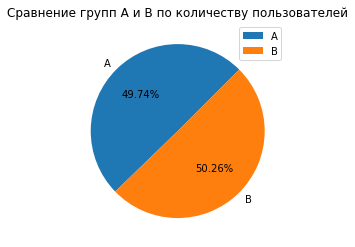

In [20]:
#Строим график для сравнения групп по количеству пользователей

plt.pie(grp_test['user_id'], 
labels=grp_test['group'], 
autopct='%1.2f%%', 
startangle=45)

plt.legend()
plt.title('Сравнение групп A и B по количеству пользователей')
plt.show()

In [21]:
#Проверим равномерность разделения пользователей по устройствам
grp_device=test_participants.groupby(['group','device'])['user_id'].nunique().reset_index()
grp_device.head()

,group,device,user_id
0,A,Android,2356
1,A,Mac,542
2,A,PC,1286
3,A,iPhone,990
4,B,Android,2320


На основе проведённого анализа A/B-теста сформулируем следующие выводы:

В группах почти одинаковое количество пользователей, разница составляет менее 1%.  
Выборочные группы независимы друг от друга, поскольку нет пользователей, которые участвовали бы в обеих группах или в других тестах одновременно.

A/B-тестирование проводится корректно.

In [22]:
#Объединим датасеты с пользователями и событиямио левому типу, чтобы сохранить данные о пользователях участвующих в тесте
df=test_participants.merge(events, on='user_id', how='left')
df.head()

,user_id,group,ab_test,device,event_dt,event_name,details
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38
1,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:49,login,NaN
2,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:57,login,NaN
3,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:38:54,login,NaN
4,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:35,login,NaN


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [23]:
df['event_dt'] = pd.to_datetime(df['event_dt'])  

#Определим дату первой активности (регистрации) для каждого пользователя
first_activity = df.groupby('user_id')['event_dt'].min().reset_index()
first_activity.rename(columns={'event_dt': 'registration_dt'}, inplace=True)

# Объединение данных с датой регистрации
df = pd.merge(df, first_activity, on='user_id', how='left')

#Расчет лайфтайма
df['lifetime'] = (df['event_dt'] - df['registration_dt']).dt.days

#Фильтруем события (оставляем только события в течение первых 7 дней)
df_filtered = df[df['lifetime'] < 7]

# Вывод информации о результатах
print(f"Исходное количество событий: {len(df)}")
print(f"Количество событий после фильтрации (лайфтайм < 7 дней): {len(df_filtered)}")

df_filtered.head()

Исходное количество событий: 76658
Количество событий после фильтрации (лайфтайм < 7 дней): 66262


,user_id,group,ab_test,device,event_dt,event_name,details,registration_dt,lifetime
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38,2020-12-07 04:37:31,0
1,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:49,login,NaN,2020-12-07 04:37:31,0
2,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:57,login,NaN,2020-12-07 04:37:31,0
3,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:38:54,login,NaN,2020-12-07 04:37:31,0
4,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:35,login,NaN,2020-12-07 04:37:31,1


Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [24]:
#Зафиксируем значения для расчета достаточности выборки
baseline_conversion_rate = 0.3  
mde = 0.1  
alpha = 0.05  
power = 0.8 

new_conversion_rate = baseline_conversion_rate * (1 + mde)

effect_size = proportion_effectsize(baseline_conversion_rate, new_conversion_rate)

power_analysis = NormalIndPower()
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    ratio=1
)

total_sample_size = sample_size * 2

print(f"Минимальный размер выборки для каждой группы: {int(sample_size)}")
print(f"Общий размер выборки: {int(total_sample_size)}")

Минимальный размер выборки для каждой группы: 3761
Общий размер выборки: 7523


In [25]:
#Создадим выборку для каждой группы
a_df=df_filtered.loc[(df_filtered['group']=='A')]['user_id']
b_df=df_filtered.loc[(df_filtered['group']=='B')]['user_id']

kol_a=a_df.nunique() 
kol_b=b_df.nunique()

kol_a, kol_b

(5174, 5229)

In [26]:
if kol_a >= sample_size and kol_b >= sample_size:
    print("Выборка достаточна для проведения теста.")
else:
    print("Выборка недостаточна. Требуется больше пользователей.")

Выборка достаточна для проведения теста.


- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [27]:
#Отфильтруем датасет по пользователям, совершающим покупки
df_purchase=df_filtered.loc[(df_filtered['event_name']=='purchase')]

#Количество уникальных пользователей:
n_a = df_filtered.loc[(df_filtered['group']=='A')]['user_id'].nunique()
n_b = df_filtered.loc[(df_filtered['group']=='B')]['user_id'].nunique()
print(f'Количество уникальных пользователей для групп А и В:{n_a, n_b}')

#Количество уникальных пользователей совершивших покупку:
m_a = df_purchase.loc[(df_purchase['group']=='A')]['user_id'].nunique()
m_b = df_purchase.loc[(df_purchase['group']=='B')]['user_id'].nunique()
print(f'Количество уникальных пользователей совершивших покупку для групп А и В:{m_a, m_b}')

p_a, p_b = m_a/n_a, m_b/n_b
print(f'Доля пользователей совершающих покупки для групп А и В:{p_a:.2f}, {p_b:.2f}')

conversion_percent=(p_b-p_a)*100
print(f'Увеличение конверсии в группе В по сравнению с группой А:{conversion_percent:.2f} процентных пунктов')

relative_conversion_percent= ((p_b-p_a)/p_b)*100
print(f'Относительное увеличение конверсии в группе В по сравнению с группой А:{relative_conversion_percent:.2f} %')

Количество уникальных пользователей для групп А и В:(5174, 5229)
Количество уникальных пользователей совершивших покупку для групп А и В:(1427, 1532)
Доля пользователей совершающих покупки для групп А и В:0.28, 0.29
Увеличение конверсии в группе В по сравнению с группой А:1.72 процентных пунктов
Относительное увеличение конверсии в группе В по сравнению с группой А:5.86 %


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

Согласно предварительным данным, в тестовой группе доля пользователей, совершающих покупку, выше на 2,2 процентных пункта по сравнению с контрольной группой, тогда как ожидаемый показатель составлял 3 пункта. Проверим статистическую значимость этих данных с помощью статистического теста.

## 4. Проведите оценку результатов A/B-тестирования:

Сформулируем гипотезу для проверки:

Нулевая гипотеза H₀: Конверсия в покупку пользователей контрольной и тестовой групп не различаются.

Альтернативная гипотеза H₁: Конверсия в покупку пользователей с новым интерфейсом больше, и это различие статистически значимо.

In [28]:
#Проверим, выполняется ли предпослыка о достаточном размере выборок

print(f'n_a={n_a}, n_b={n_b}')


print(f'm_a={m_a}, m_b={m_b}')


print(f'p_a={p_a}, p_b={p_b}')


if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

n_a=5174, n_b=5229
m_a=1427, m_b=1532
p_a=0.2758020873598763, p_b=0.29298144960795564
Предпосылка о достаточном количестве данных выполняется!


In [29]:
#Используем z-тест пропорций, для проверки гипотезы

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller' # так как H_1: p_a < p_b
)


if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
    print('Интерпритация: Вероятность покупки, согласно результатам статистического теста, равна для групп А и В.')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')
    print('Интерпритация: Альтернативная гипотеза, о том что в группе В, вероятность покупки больше, согласно результатам статистического теста, находит подтверждение.')

pvalue=0.026072886604683897 < 0.05
Нулевая гипотеза не находит подтверждения!
Интерпритация: Альтернативная гипотеза, о том что в группе В, вероятность покупки больше, согласно результатам статистического теста, находит подтверждение.


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

- Для проведения теста мы определили минимальный размер выборки для каждой группы — он составил 3761 человек. Реальный размер выборок обеих групп превысил это значение. Мы отслеживали конверсию в покупку как основную метрику.
- Изменение интерфейса сайта для тестовой группы привело к статистически значимому увеличению количества покупок по сравнению с контрольной группой.
- Значение p-value составило 0,007041421154716094, что значительно меньше установленного уровня значимости. Это позволяет считать эффект от изменений статистически значимым.
- Конверсия увеличилась на 2,2 процентных пункта, тогда как ожидаемый показатель составлял 3 пункта — желаемый эффект не был достигнут полностью.
- Учитывая жалобы пользователей на старый интерфейс и наличие статистически значимого эффекта от изменений, мы рекомендуем внедрить новый интерфейс для всех пользователей. Для достижения нужной конверсии важно следить за динамикой и при необходимости вносить дополнительные доработки.